# PBC3.py test

In [1]:
from PBC3 import PBC3, PBC3Config
from PBC2_4 import PBC as PBC2
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import os
import time

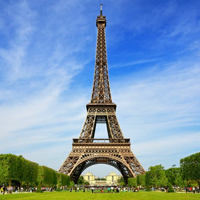

In [2]:
img = Image.open("test_images/eiffel.png")
img.resize((200, 200))

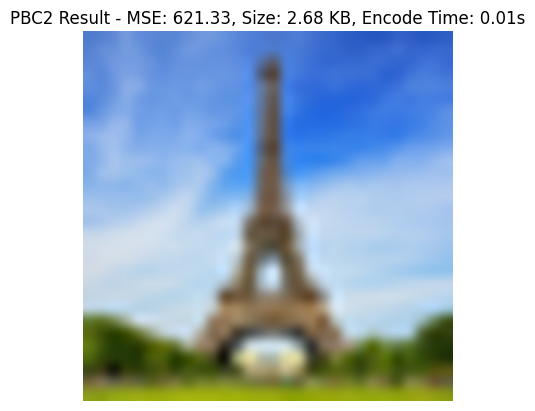

In [3]:
res = PBC2.compress(img, stroke_count=0)
res.show()

MSE: 336.3179626464844, Compressed Size: 7.66 KB
Verification successful: Encoded and decoded images are identical.


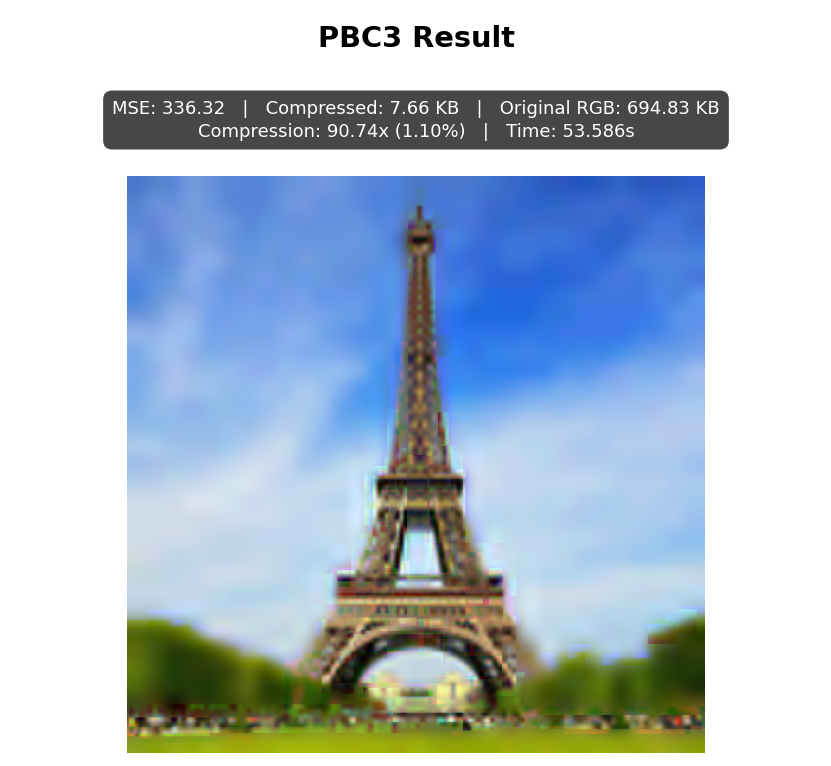

In [33]:
cfg = PBC3Config(
    downsample_cell_size=16,
    downsample_palette_bitcount=5,
    patch_palette_bitcount=4,
    mask_size=16,
    patch_count=100,

    search_depth=150,
    proposal_depth=150,
    top_k=10,
    anchor_block_size=5,

    min_patch_size=8,
    max_patch_size=256,
    min_cell_size=1,
    max_cell_size=16,
    cell_sizes_per_candidate=1,
)

res = PBC3.compress(img, cfg)
decoded = PBC3.decompress(res.data)

print(f"MSE: {res.mse}, Compressed Size: {len(res.data) / 1024:.2f} KB")
if res.verify():
    print("Verification successful: Encoded and decoded images are identical.")
    res.show()
else:
    print("Verification failed: Encoded and decoded images differ.")
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("Encoded Image")
    plt.imshow(res.image)
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title("Decoded Image")
    plt.imshow(decoded.image)
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.title("Difference")
    diff = np.abs(np.array(res.image).astype(int) - np.array(decoded.image).astype(int))
    plt.imshow(diff)
    plt.axis("off")
    plt.show()

In [ ]:
cfg = PBC3Config(
    downsample_cell_size=16,
    downsample_palette_bitcount=5,
    patch_palette_bitcount=4,
    mask_size=16,
    patch_count=200,

    search_depth=1,
    proposal_depth=1,
    top_k=1,
    anchor_block_size=5,

    min_patch_size=8,
    max_patch_size=256,
    min_cell_size=1,
    max_cell_size=16,
    cell_sizes_per_candidate=1,
)

res = PBC3.compress(img, cfg)

print(f"MSE: {res.mse}, Compressed Size: {len(res.data) / 1024:.2f} KB")
if res.verify():
    print("Verification successful: Encoded and decoded images are identical.")
    res.show()
else:
    print("Verification failed: Encoded and decoded images differ.")
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("Encoded Image")
    plt.imshow(res.image)
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title("Decoded Image")
    plt.imshow(decoded.image)
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.title("Difference")
    diff = np.abs(np.array(res.image).astype(int) - np.array(decoded.image).astype(int))
    plt.imshow(diff)
    plt.axis("off")
    plt.show()

In [72]:
res.save("testing.pbc")

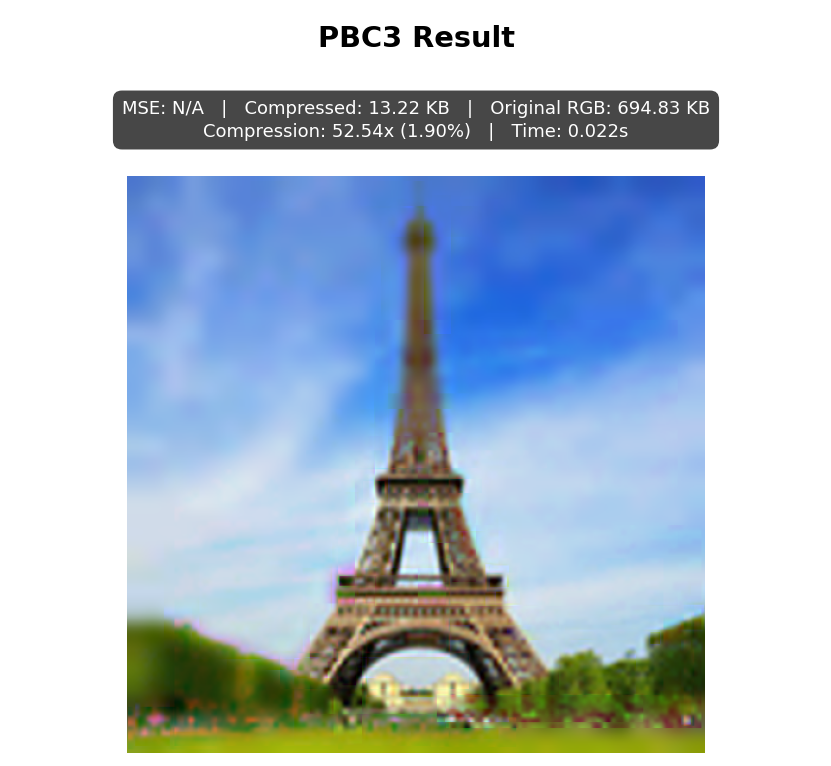

In [71]:
PBC3.decompress(res.data).show()

---

MSE: 329.50701904296875, Compressed Size: 7.54 KB
Verification successful: Encoded and decoded images are identical.


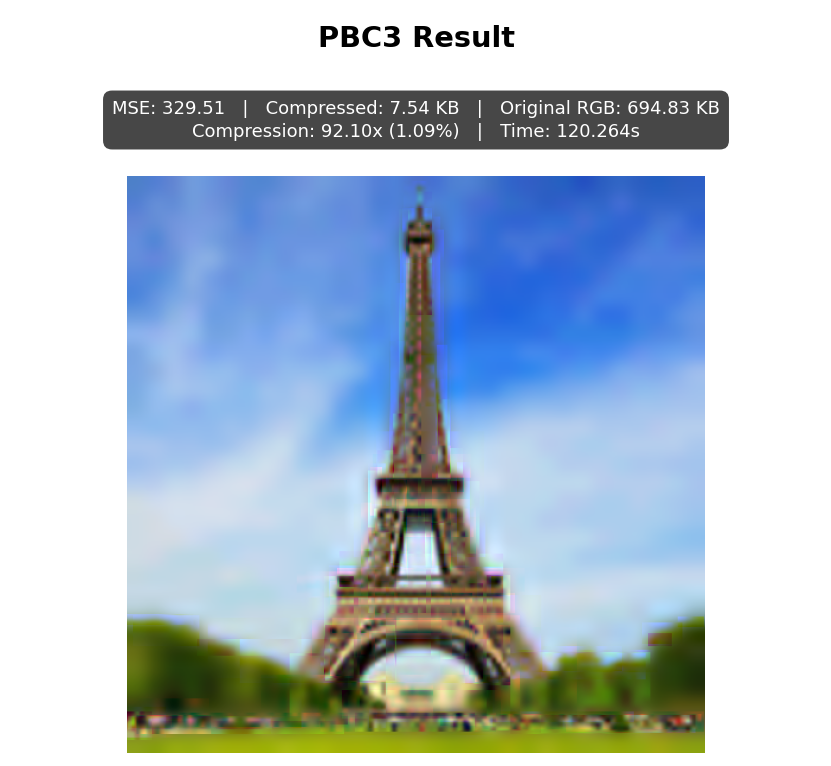

In [54]:
cfg = PBC3Config(
    downsample_cell_size=16,
    downsample_palette_bitcount=5,
    patch_palette_bitcount=4,
    mask_size=8,
    patch_count=100,

    search_depth=1000,
    proposal_depth=250,
    top_k=20,
    anchor_block_size=5,

    min_patch_size=8,
    max_patch_size=256,
    min_cell_size=1,
    max_cell_size=16,
    cell_sizes_per_candidate=2,
)

res = PBC3.compress(img, cfg)

print(f"MSE: {res.mse}, Compressed Size: {len(res.data) / 1024:.2f} KB")
if res.verify():
    print("Verification successful: Encoded and decoded images are identical.")
    res.show()
else:
    print("Verification failed: Encoded and decoded images differ.")
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("Encoded Image")
    plt.imshow(res.image)
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title("Decoded Image")
    plt.imshow(decoded.image)
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.title("Difference")
    diff = np.abs(np.array(res.image).astype(int) - np.array(decoded.image).astype(int))
    plt.imshow(diff)
    plt.axis("off")
    plt.show()

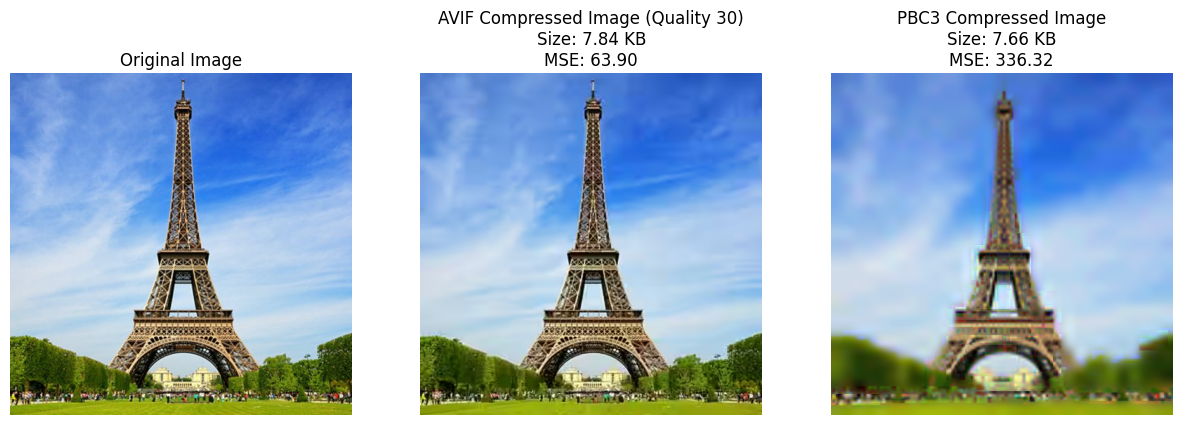

In [46]:
# compress the img with AVIF at quality n, and compare the compression rate and quality
avif_quality = 30
avif_path = f"test_images/eiffel_avif_q{avif_quality}.avif"
if not os.path.exists(avif_path):
    img.save(avif_path, format="AVIF", quality=avif_quality)

avif_img = Image.open(avif_path)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")
plt.subplot(1, 3, 2)
plt.title(f"AVIF Compressed Image (Quality {avif_quality})\nSize: {os.path.getsize(avif_path) / 1024:.2f} KB\nMSE: {np.mean((np.array(img).astype(float) - np.array(avif_img).astype(float)) ** 2):.2f}")
plt.imshow(avif_img)
plt.axis("off")
plt.subplot(1, 3, 3)
plt.title(f"PBC3 Compressed Image\nSize: {len(res.data) / 1024:.2f} KB\nMSE: {res.mse:.2f}")
plt.imshow(decoded.image)
plt.axis("off")
plt.show()

In [56]:
img2 = Image.open("test_images/ege.JPG")

cfg = PBC3Config(
    downsample_cell_size=16,
    downsample_palette_bitcount=5,
    patch_palette_bitcount=4,
    mask_size=16,
    patch_count=50,

    search_depth=500,
    proposal_depth=15,
    top_k=10,
    anchor_block_size=5,

    min_patch_size=8,
    max_patch_size=256,
    min_cell_size=1,
    max_cell_size=16,
    cell_sizes_per_candidate=1,
)

res = PBC3.compress(img2, cfg)

print(f"MSE: {res.mse}, Compressed Size: {len(res.data) / 1024:.2f} KB")
if res.verify():
    print("Verification successful: Encoded and decoded images are identical.")
    res.show()
else:
    print("Verification failed: Encoded and decoded images differ.")
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("Encoded Image")
    plt.imshow(res.image)
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title("Decoded Image")
    plt.imshow(decoded.image)
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.title("Difference")
    diff = np.abs(np.array(res.image).astype(int) - np.array(decoded.image).astype(int))
    plt.imshow(diff)
    plt.axis("off")
    plt.show()

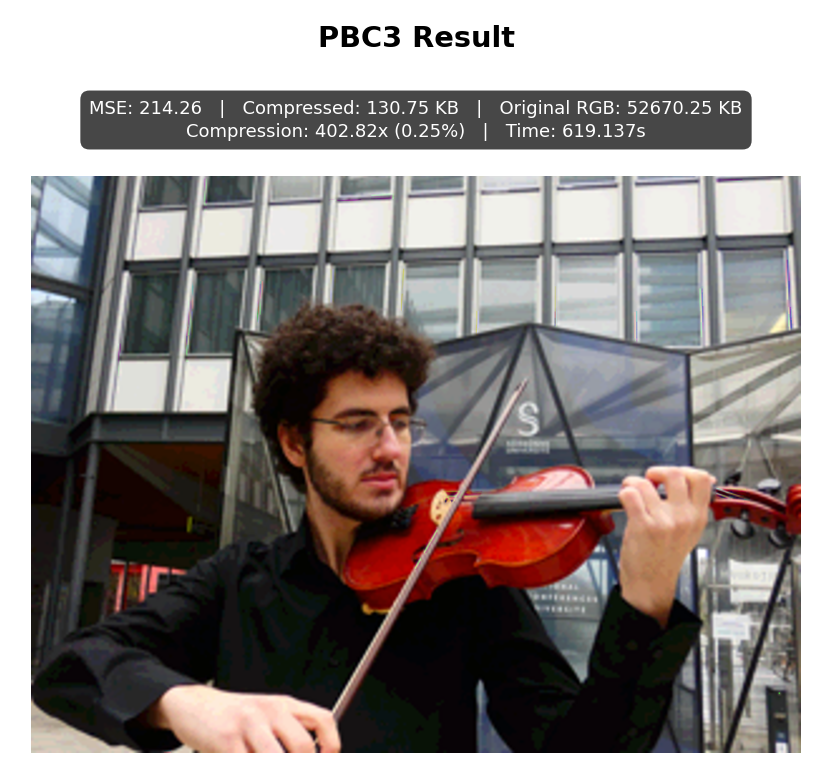

In [61]:
res.show()

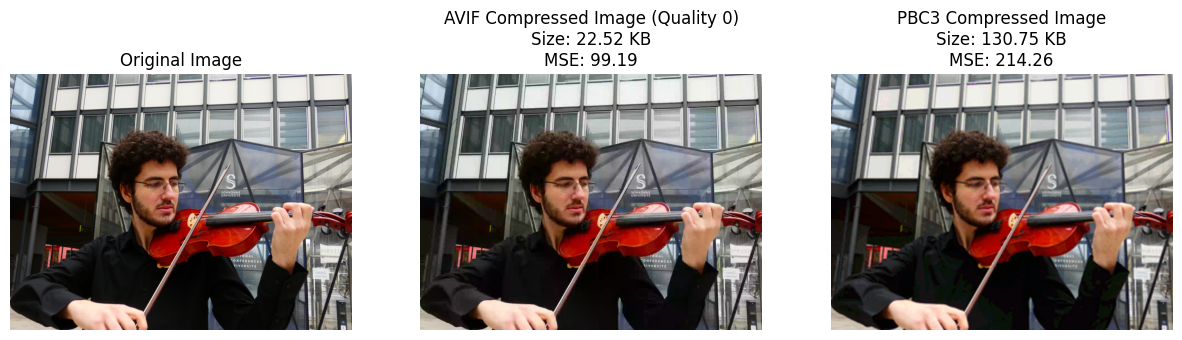

In [62]:
# compress the img with AVIF at quality n, and compare the compression rate and quality
avif_quality = 0
avif_path = f"test_images/ege_avif_q{avif_quality}.avif"
if not os.path.exists(avif_path):
    img2.save(avif_path, format="AVIF", quality=avif_quality)

avif_img = Image.open(avif_path)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img2)
plt.axis("off")
plt.subplot(1, 3, 2)
plt.title(f"AVIF Compressed Image (Quality {avif_quality})\nSize: {os.path.getsize(avif_path) / 1024:.2f} KB\nMSE: {np.mean((np.array(img2).astype(float) - np.array(avif_img).astype(float)) ** 2):.2f}")
plt.imshow(avif_img)
plt.axis("off")
plt.subplot(1, 3, 3)
plt.title(f"PBC3 Compressed Image\nSize: {len(res.data) / 1024:.2f} KB\nMSE: {res.mse:.2f}")
plt.imshow(res.image)
plt.axis("off")
plt.show()

In [63]:
52670/22.52

2338.809946714032